# TUTORIAL
# Create synthetic truth and observations



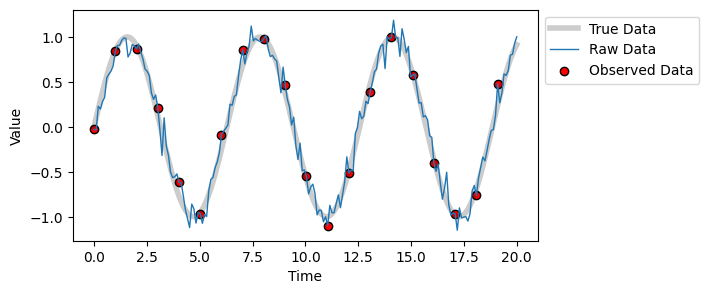

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np


t = np.linspace(0, 20, 200)

true_data = np.sin(t)
raw_data = true_data + 0.1 * np.random.randn(len(t))  # Add a noise to the true data
dt_obs = 10
observed_data = raw_data[::dt_obs] 

plt.figure(figsize=(6, 3))
plt.plot(t, true_data, c='k', alpha=.2, lw=4, label='True Data')
plt.plot(t, raw_data, c='C0', lw=1, label='Raw Data')
plt.scatter(t[::dt_obs], observed_data, color='red', label='Observed Data', edgecolors='k')
plt.xlabel('Time'), plt.ylabel('Value'), plt.legend(loc='upper left', bbox_to_anchor=(1, 1));

### 1. Create timeseries from the low-order model

Note that this data is clean and biased. Both the noise and the bias will be added in the next steps.

OK: Observations initialized.


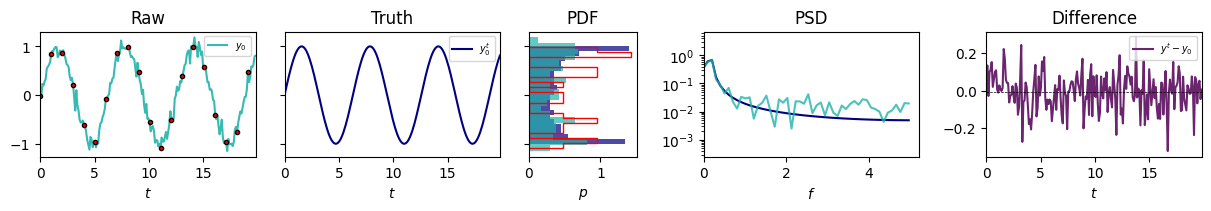

In [2]:
from observations import Observations

reference_data = Observations(y_true=true_data, 
                              y_raw=raw_data,
                              t_true=t, 
                              Nt_obs=10
                              )

Observations.plot_truth(reference_data, window=20)

Instead of providing the dataset, we can create the observations from a model. For instance, using the Lorenz 63 model.

Loaded true data model: Truth_Lorenz63_beta3.0 <models_physical.lorenz63.Lorenz63 object at 0x7f611c4a2710>
OK: Observations initialized.


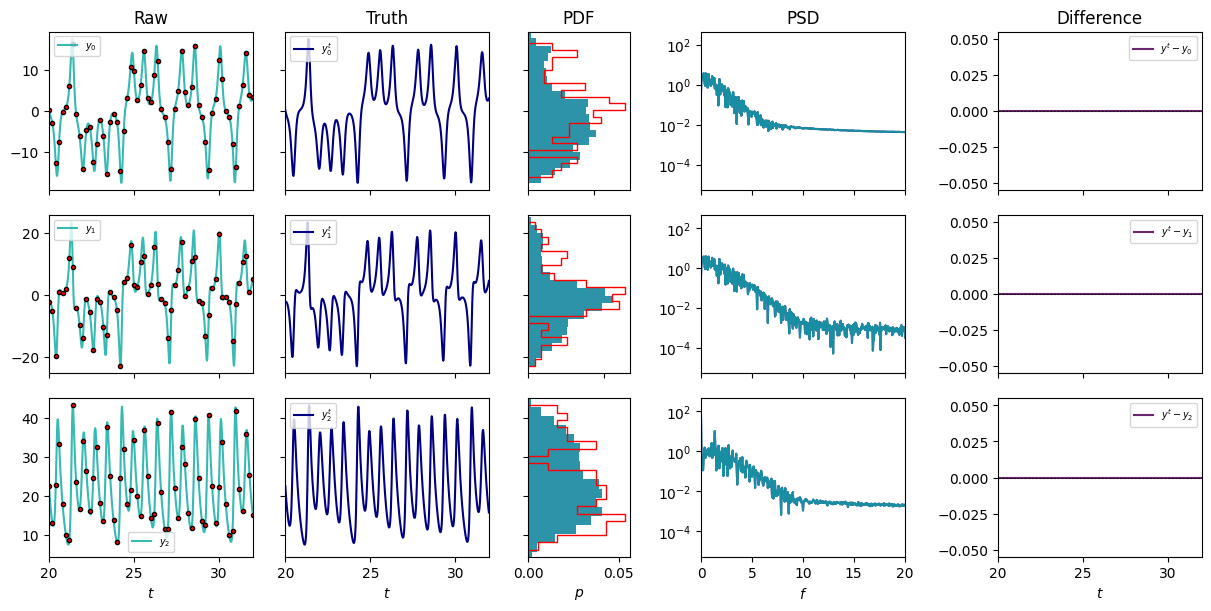

In [3]:
from models_physical import Lorenz63
from utils import set_working_directories

results_dir = set_working_directories('Lorenz63')[1]

truth = Observations(model=Lorenz63, 
                     beta=3.,
                     t_start=20.0, 
                     t_stop=40.0, 
                     Nt_obs=10, 
                     results_folder=results_dir)


Observations.plot_truth(truth, Nq=3, f_max=20)

### 3. Add noise to the truth to create the observations

The noise type can be selected between Gaussian  or coloured noise (from colours white, pink, brown, blue, and violet). Further, one can define the noise to be either [additive] or multiplicative. 
- The bias is added in the initialization of the `Observations` instance via the `_apply_noise` function. Note: 'gaussian, additive' is the pre-defined setting.
- The function ```utils.colour_noise``` allows us to add different types of noises. We can visualize the different options.


...Adding noise: gauss, add with level 0.05.
OK: Observations initialized.


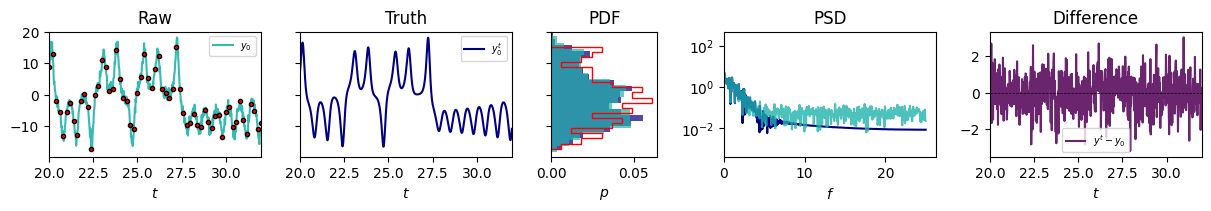

In [4]:
truth_noisy = Observations(model=Lorenz63, 
                            t_start=20.0, 
                            t_stop=40.0, 
                            Nt_obs=10, 
                            add_noise=True,
                            noise_type='gauss, add',
                            noise_level=0.05)

Observations.plot_truth(truth_noisy,Nq=1)

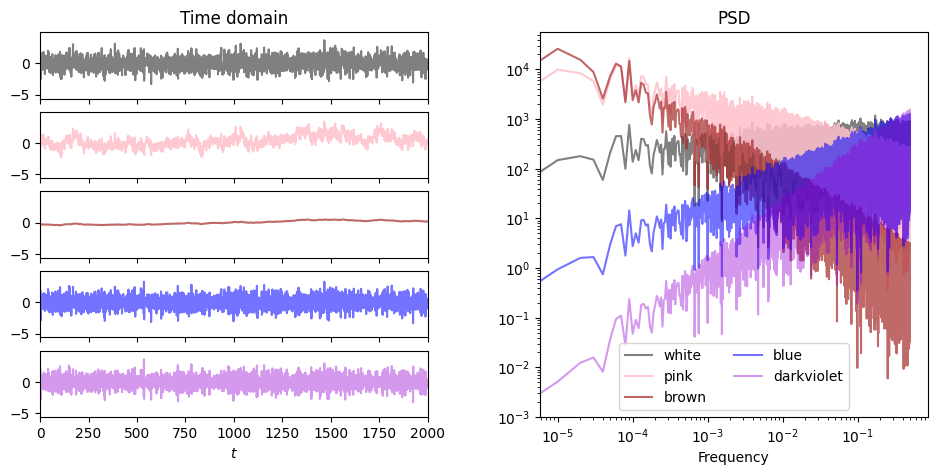

In [5]:
import matplotlib.pyplot as plt
from utils import colour_noise
import numpy as np

rng = np.random.default_rng(6)

noise_level = 0.02
noise_type = 'pink' + 'additive' 


N = 100000

noise_white = np.fft.rfft(rng.standard_normal(N))
freq = np.fft.rfftfreq(N)

NOISES, PSDS = [], []
COLOURS = ['white', 'pink', 'brown', 'blue', 'darkviolet']
for noise_c in COLOURS:
    S = colour_noise(N, noise_colour=noise_c)
    S = noise_white * S 
    noise = np.fft.irfft(S)  # transform back into time domain

    # Store
    PSDS.append(abs(S))
    NOISES.append(noise)
    

fig = plt.figure(figsize=(10, 5))
figs = fig.subfigures(1, 2)
ax = figs[1].subplots(1, 1)
alpha = 1
for psd, c in zip(PSDS, COLOURS):
    c = c if c != 'white' else 'gray'
    ax.loglog(freq, psd, color=c, alpha=alpha)
    alpha -= 0.15
ax.legend(COLOURS, ncol=2)
ax.set(xlabel='Frequency', ylim=[1e-3, None], title='PSD')
    
axs = figs[0].subplots(len(COLOURS), 1, sharex='col', sharey='col')
alpha = 1
N_plot = 1000
for ax, noise, c in zip(axs, NOISES, COLOURS):
    c = c if c != 'white' else 'gray'
    ax.plot(np.arange(N), noise, color=c, alpha=alpha)
    alpha -= 0.15
axs[0].set(title='Time domain', xlim=[0, 2*N_plot])
axs[-1].set(xlabel='$t$');


We can observe that
* White noise has an almost-flat PSD in the frequency domain, i.e., all the frequencies are equally present
* Brownian and pink noises strength is lowest at higher frequencies, which is visualized in the time domain with seamingly non-zero mean.
* Blue and violet noise strenght increases with the frequency.

### 2. (optional) Add bias

If we do not add the bias, then the Model is unbiased. Alternatively, 

$$
\mathbf{y}^\mathrm{true} =  \mathbf{y}^\mathrm{Model} + \mathbf{b}^\mathrm{true}
$$

then the prediction from the Model becomes biased. The bias is added in the initialization of the `Observations` instance via the `_set_bias` function.



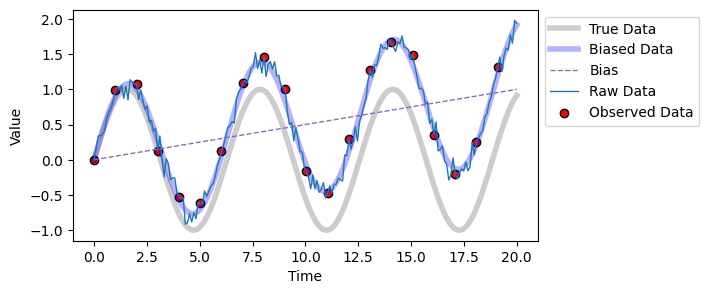

In [6]:

t = np.linspace(0, 20, 200)

true_data = np.sin(t) 
bias = 0.05 * t # for intance, a time drift
biased_data = true_data + bias # this is noise-free but biased data
raw_data = biased_data + 0.1 * np.random.randn(len(t))  # Add a noise to the true data
dt_obs = 10
observed_data = raw_data[::dt_obs] 

plt.figure(figsize=(6, 3))
plt.plot(t, true_data, c='k', alpha=.2, lw=4, label='True Data')
plt.plot(t, biased_data, c='b', alpha=.3, lw=4, label='Biased Data')
plt.plot(t, bias, c='C4', ls='--', lw=1, label='Bias')
plt.plot(t, raw_data, c='C0', lw=1, label='Raw Data')
plt.scatter(t[::dt_obs], observed_data, color='red', label='Observed Data', edgecolors='k')
plt.xlabel('Time'), plt.ylabel('Value'), plt.legend(loc='upper left', bbox_to_anchor=(1, 1));

In [7]:
help(Observations._set_bias)

Help on function _set_bias in module observations:

_set_bias(self)
    Applies manual or default bias to zero.
    Options:
    - manual_bias = None (no bias)
    - manual_bias = string (predefined bias types: 'linear', 'periodic', 'time', 'cosine')
    - manual_bias = function(y_true, t_true) returning (b_true, name_bias)
    Returns:
    - b_true: bias array,
    - name_bias: string description of bias type



...Applying manual bias: time
...Adding noise: gauss, add with level 0.05.
OK: Observations initialized.


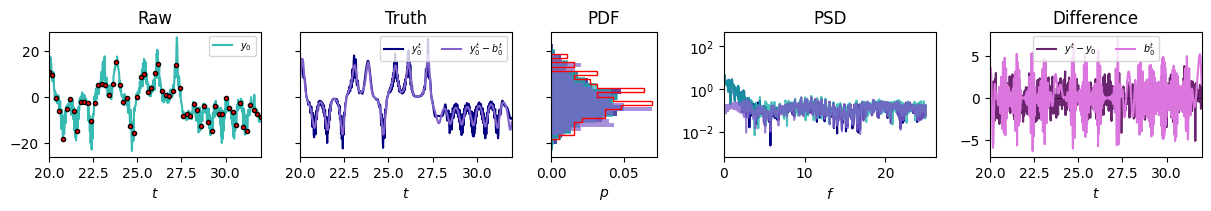

In [8]:
truth_noisy_biased = Observations(model=Lorenz63, 
                            t_start=20.0, 
                            t_stop=40.0, 
                            Nt_obs=10, 
                            add_noise=True,
                            noise_type='gauss, add',
                            noise_level=0.05,
                            manual_bias='time')


Observations.plot_truth(truth_noisy_biased,Nq=1)

In [9]:
# Alternative: user-defined bias function
def my_bias_function(y, t):
    """Example of user-defined bias function."""
    b = 0.1 * t[:, np.newaxis, np.newaxis] + .2*abs(y)  
    return b, 'mybias'  

...Applying user-defined manual bias
...Adding noise: gauss, add with level 0.05.
OK: Observations initialized.


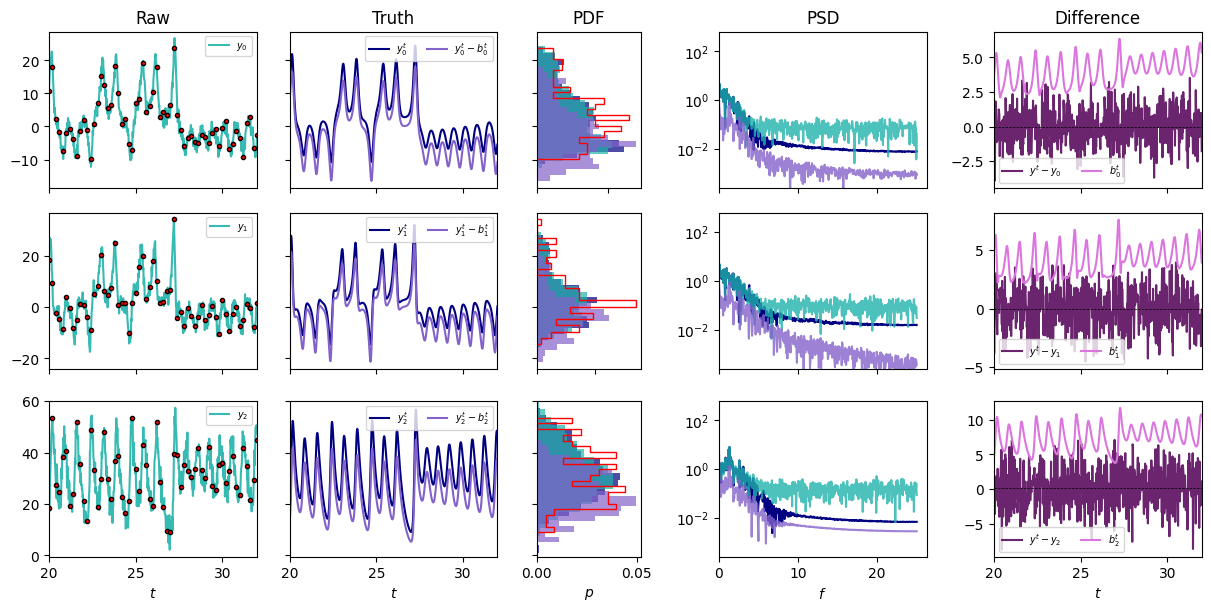

In [10]:
truth_noisy_biased = Observations(model=Lorenz63, 
                            t_start=20.0, 
                            t_stop=40.0, 
                            Nt_obs=10, 
                            add_noise=True,
                            noise_type='gauss, add',
                            noise_level=0.05,
                            manual_bias=my_bias_function)


Observations.plot_truth(truth_noisy_biased, Nq=3)